In [1]:
# !pip install matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
pd.set_option("display.float_format","{:,.2f}".format)


In [2]:
base_dir = Path.cwd()
df = pd.read_parquet(f'{base_dir}/files/sales.parquet')

In [3]:
# setting the RFM to my clients
clientes = df.groupby('cliente').agg(
    montoventapesos = ('montoventapesos','sum'),
    frecuencia = ('factura', 'nunique'),
    recencia = ('fechafactura',lambda x: (pd.Timestamp.now()-x.max()).days)
).reset_index()


# First sight to the distribution of my data

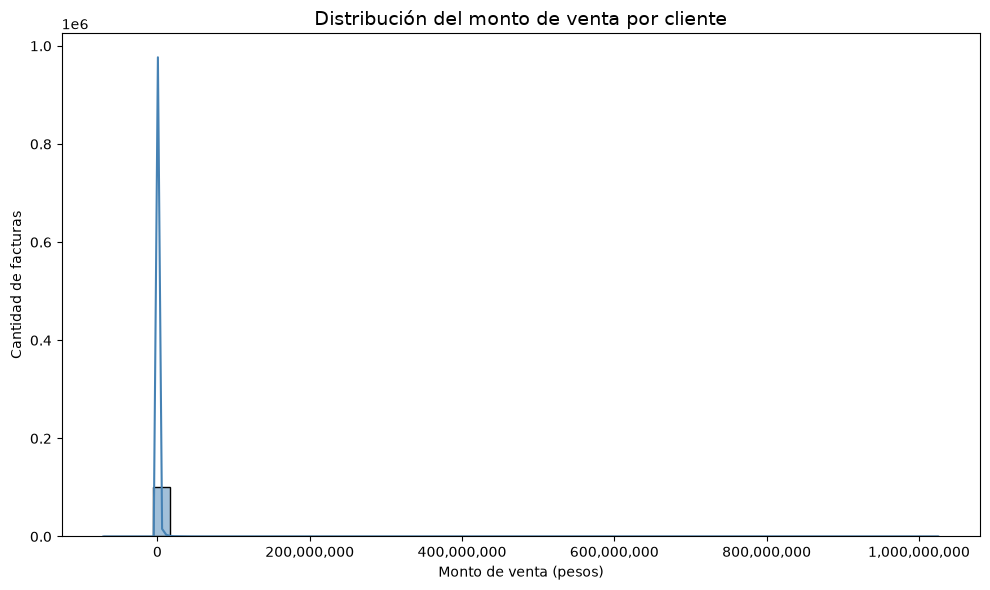

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=clientes,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=ax
)
ax.set_title('Distribución del monto de venta por cliente', fontsize=14)
ax.set_xlabel('Monto de venta (pesos)')
ax.set_ylabel('Cantidad de facturas')
#ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

> ***The data is skewed to the the right, so in this ocassion we are going to apply a log scale (I have done some researchs to look for it)***

In [5]:
devoluciones = clientes[clientes['montoventapesos']<=0]
clientes_positivos = clientes[clientes['montoventapesos']>0]
q1 = clientes['montoventapesos'].quantile(0.25)
q3 = clientes['montoventapesos'].quantile(0.75)
clientes_IQR = clientes_positivos[(clientes_positivos['montoventapesos']>=q1) &(clientes_positivos['montoventapesos']<=q3)]
clientes_higher_q3 = clientes_positivos[(clientes_positivos['montoventapesos']>q3)]
clientes_lower_q1 = clientes_positivos[(clientes_positivos['montoventapesos']<q1)]


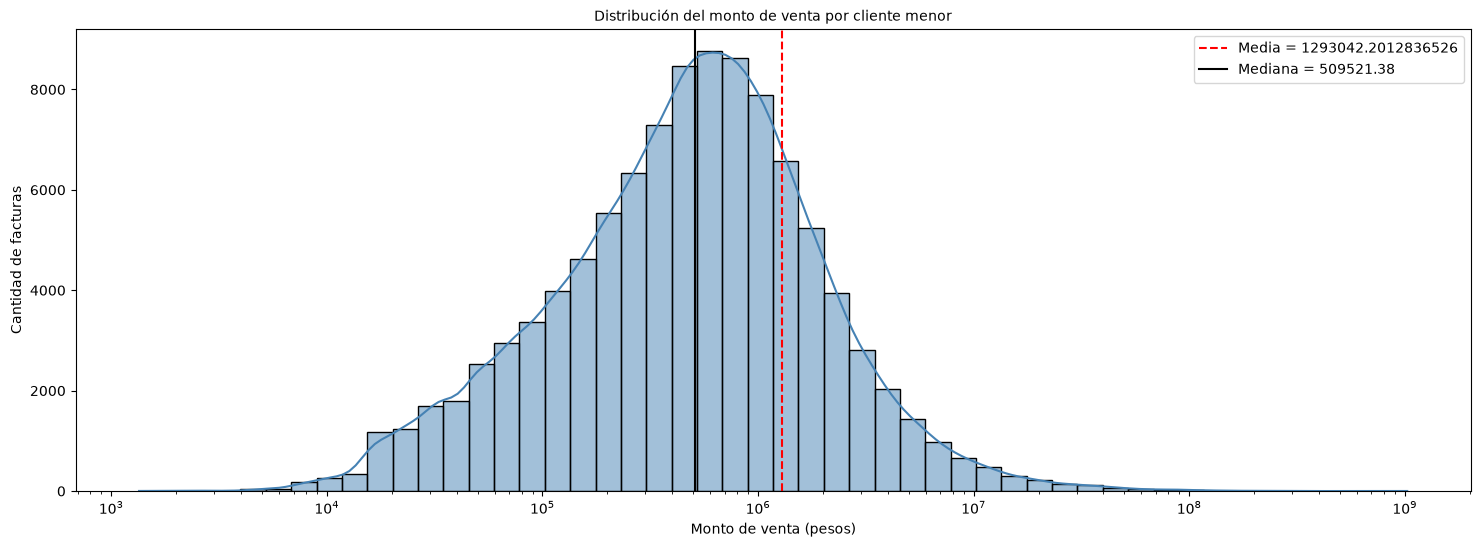

In [6]:
fig, axes = plt.subplots(figsize=(18, 6))
sns.histplot(
    data=clientes_positivos,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=axes,
    log_scale=True
)

media = clientes_positivos['montoventapesos'].mean()
median = clientes_positivos['montoventapesos'].median() 
axes.set_title('Distribución del monto de venta por cliente menor', fontsize=10)
axes.set_xlabel('Monto de venta (pesos)')
axes.set_ylabel('Cantidad de facturas')
axes.axvline(media,label=f'Media = {media}', color= 'red',linestyle='--')
axes.axvline(median,label=f'Mediana = {median}', color= 'black',linestyle='-')
#axes[0].ticklabel_format(style='plain', axis='x')
#axes.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes.legend()

# **Machine Learning**
---

## Escalar los datos

In [ ]:
from sklearn.preprocessing import QuantileTransformer

variables = ['frecuencia','recencia','montoventapesos']
x = clientes_positivos[variables].values
x_scaled = QuantileTransformer(output_distribution='normal', random_state=42).fit_transform(x)

x_scaled

 


array([[ 0.21620388, -0.300542  , -0.43612375],
       [-1.2127505 , -1.1595152 , -0.56194709],
       [-0.96942671,  1.08476239, -1.33905371],
       ...,
       [ 2.07444461,  0.1625524 ,  2.70727852],
       [ 1.99497097, -1.68967008,  2.57884854],
       [ 1.45327957, -0.48083942,  1.547965  ]], shape=(102243, 3))

> Take into account the a ***log10*** for 0 y ***-inf*** so it gives and error

In [29]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

clientes_positivos['pca1'] = x_pca[:,0]
clientes_positivos['pca2'] = x_pca[:,1]


pd.DataFrame(
    data=pca.components_,
    columns=variables,
    index=['PCA1','PCA2']
)




,frecuencia,recencia,montoventapesos
PCA1,0.81,-0.41,0.42
PCA2,0.40,0.91,0.11


<Axes: xlabel='pca1', ylabel='pca2'>

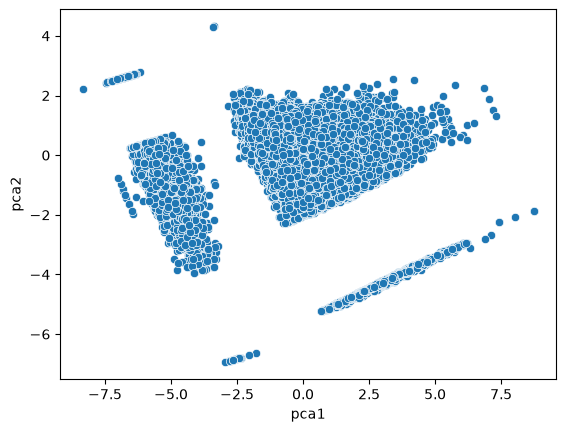

In [30]:
plt.Figure(figsize=(10,14))
sns.scatterplot(
    data=clientes_positivos,
    x=clientes_positivos['pca1'],
    y=clientes_positivos['pca2']
)